<a href="https://colab.research.google.com/github/arman871/Electronic-Shop-Operational-Insights/blob/main/E_commerce_Retail_%26_Operations_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Success: Dataset Loaded Successfully!
✅ Success: 'Total_Sales' column calculated.



/tmp/ipython-input-350/4052279037.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_sales, x='channel_of_ordering', y='Total_Sales', palette='viridis')


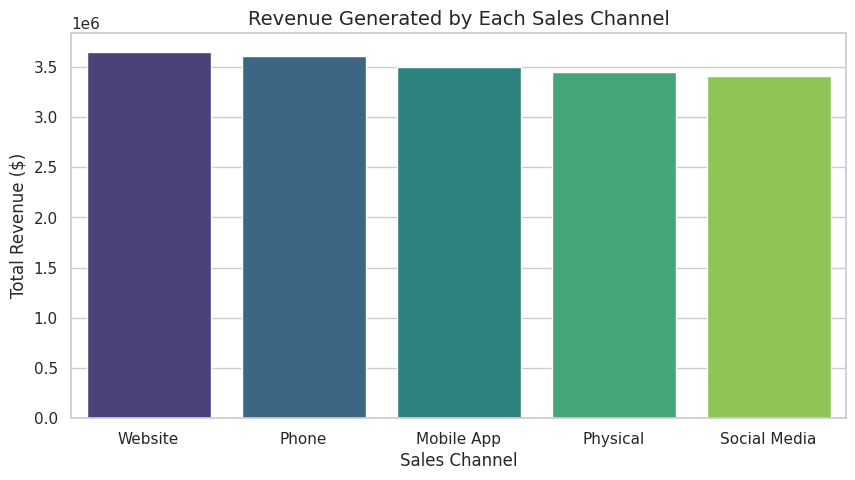

--- TOP 5 PRODUCTS BY REVENUE ---
product_name
Drone            2537181.00
Camera           2189449.14
Laptop           1749381.14
Smart TV         1629071.19
Graphics Card    1562753.13
Name: Total_Sales, dtype: float64




/tmp/ipython-input-350/4052279037.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index, palette='magma')


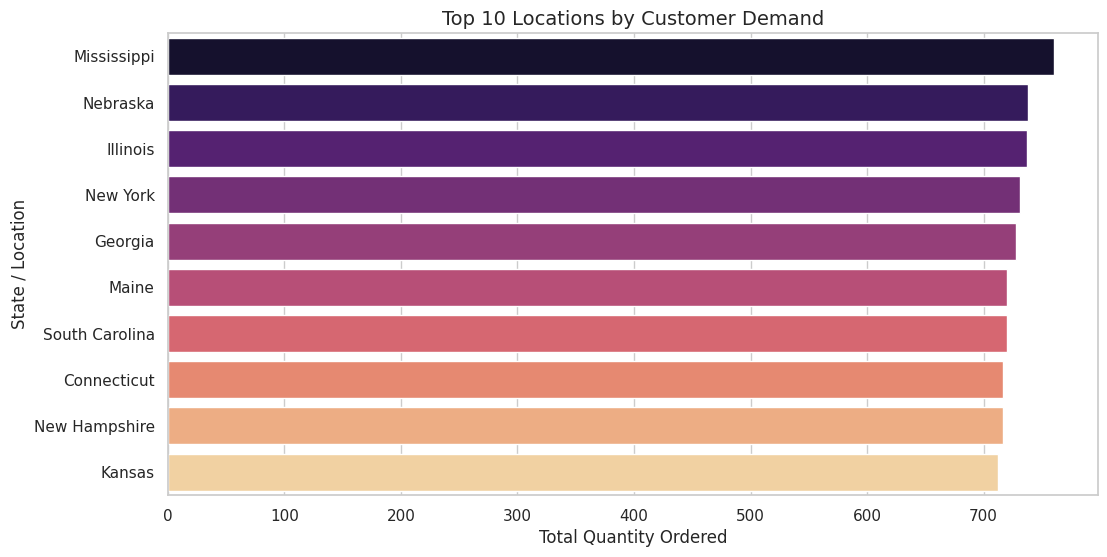

--- ORDER STATUS SUMMARY ---
order_status
In Process    2783
Delivered     2755
On Hold       2751
Canceled      2711
Name: count, dtype: int64

✅ PROJECT COMPLETE: All visualizations and insights generated.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for the charts
sns.set(style="whitegrid")

# 1. LOAD THE DATASET
file_name = 'Electonic Shop Dataset.csv'

try:
    df = pd.read_csv(file_name)
    print("✅ Success: Dataset Loaded Successfully!")

    # 2. DATA TRANSFORMATION
    # Creating a new column 'Total_Sales' by multiplying price and quantity
    df['Total_Sales'] = df['product_price'] * df['number_of_ordered_items']
    print("✅ Success: 'Total_Sales' column calculated.\n")

    # 3. SALES CHANNEL ANALYSIS (Which platform makes the most money?)
    channel_sales = df.groupby('channel_of_ordering')['Total_Sales'].sum().sort_values(ascending=False).reset_index()

    plt.figure(figsize=(10, 5))
    sns.barplot(data=channel_sales, x='channel_of_ordering', y='Total_Sales', palette='viridis')
    plt.title('Revenue Generated by Each Sales Channel', fontsize=14)
    plt.xlabel('Sales Channel')
    plt.ylabel('Total Revenue ($)')
    plt.show()

    # 4. TOP 5 BEST SELLING PRODUCTS
    print("--- TOP 5 PRODUCTS BY REVENUE ---")
    top_products = df.groupby('product_name')['Total_Sales'].sum().sort_values(ascending=False).head(5)
    print(top_products)
    print("\n")

    # 5. GEOGRAPHIC ANALYSIS (Where are the customers?)
    # Top 10 Locations based on total items ordered
    top_locations = df.groupby('location')['number_of_ordered_items'].sum().sort_values(ascending=False).head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_locations.values, y=top_locations.index, palette='magma')
    plt.title('Top 10 Locations by Customer Demand', fontsize=14)
    plt.xlabel('Total Quantity Ordered')
    plt.ylabel('State / Location')
    plt.show()

    # 6. OPERATIONS CHECK (Order Fulfillment Status)
    print("--- ORDER STATUS SUMMARY ---")
    order_status = df['order_status'].value_counts()
    print(order_status)

    # 7. FINAL SUMMARY
    print("\n✅ PROJECT COMPLETE: All visualizations and insights generated.")

except FileNotFoundError:
    print("❌ Error: The file 'Electonic Shop Dataset.csv' was not found. Please upload it to the Colab sidebar.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")